In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
np.random.seed(42)

# Read Data Files

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")
submission_file = pd.read_csv("dataset/sample_submission.csv")

In [3]:
train_data["Selling_Price"].fillna(0, inplace=True)
train_data["Selling_Price"] = np.where(train_data["Selling_Price"]<0 , 0 ,train_data["Selling_Price"])
train_data.head()

,Product_id,Stall_no,instock_date,Market_Category,Customer_name,Loyalty_customer,Product_Category,Grade,Demand,Discount_avail,charges_1,charges_2 (%),Minimum_price,Maximum_price,Selling_Price
0,BRAE2NF6JA5GUEXG,37.0,2015-08-22 18:36:12.000,2,Lillyann,Yes,Fashion,1,68,0.0,376.0,11.0,2983.0,4713.0,4185.947700
1,TUNE8SFB6RJN2HSD,38.0,2016-03-27 21:19:13.000,24,Klynn,Yes,Fashion,0,51,0.0,397.0,12.0,7495.0,10352.0,9271.490256
2,BRAEAR7WZPQGPBZU,9.0,2015-08-18 19:25:22.000,447,Ridge,Yes,Child_care,0,10,0.0,250.0,9.0,5752.0,7309.0,6785.701362
3,WATDZ2ZQ8JPDHCTJ,50.0,2016-03-28 21:53:01.000,23,Abran,Yes,Educational,2,48,0.0,144.0,13.0,5090.0,20814.0,13028.917824
4,JWSEBUKYQPMBZ3RK,7.0,2016-03-29 22:58:53.000,63,Dustyn,Yes,Repair,1,35,1.0,211.0,4.0,2430.0,9261.0,906.553935


In [4]:
test_data.head()

,Product_id,Stall_no,instock_date,Market_Category,Customer_name,Loyalty_customer,Product_Category,Grade,Demand,Discount_avail,charges_1,charges_2 (%),Minimum_price,Maximum_price
0,SCHE4YSTDVPVZVXW,39.0,2016-01-13 07:45:08.000,205,Ivanka,No,Fashion,0,90,0,380.0,16.0,2576.0,3340
1,ACCEGCATKHNRXUHW,49.0,2015-08-23 20:37:05.000,3,Isaak,Yes,Fashion,0,87,0,393.0,16.0,1202.0,1955
2,NKCE6GJ5XVJDXNNZ,1.0,2015-11-14 18:12:39.000,183,Analiese,No,Technology,2,55,0,493.0,9.0,7175.0,15715
3,NKCEB8BK3ZXDHDHM,8.0,2015-11-21 04:56:19.000,358,Rusty,Yes,Child_care,3,86,0,303.0,16.0,5404.0,13078
4,TOPEFDXSAHRNPF94,33.0,2015-05-06 15:09:46.000,167,Eloise,No,Technology,0,27,0,567.0,16.0,4069.0,6244


In [5]:
submission_file.head()

,Product_id,Selling_Price
0,SCHE4YSTDVPVZVXW,3294.594688
1,ACCEGCATKHNRXUHW,1945.603968
2,NKCE6GJ5XVJDXNNZ,11871.830880
3,NKCEB8BK3ZXDHDHM,9421.143424
4,TOPEFDXSAHRNPF94,5717.420625


In [6]:
train_data.describe(include="all")

,Product_id,Stall_no,instock_date,Market_Category,Customer_name,Loyalty_customer,Product_Category,Grade,Demand,Discount_avail,charges_1,charges_2 (%),Minimum_price,Maximum_price,Selling_Price
count,6368,6363.000000,6368,6368.000000,6157,6368,6368,6368.000000,6368.000000,6330.000000,6170.000000,6163.000000,6330.000000,6025.000000,6368.000000
unique,6368,NaN,5350,NaN,5900,2,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,BRAE2NF6JA5GUEXG,NaN,2015-09-22 15:24:59.000,NaN,Kennedy,Yes,Pet_care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,6,NaN,2,3887,682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,25.309445,NaN,199.340609,NaN,NaN,NaN,0.643687,50.921168,0.140442,264.514100,10.146195,3531.349763,6432.545892,4542.389107
std,NaN,14.328980,NaN,170.275570,NaN,NaN,NaN,1.025092,29.091922,0.347473,124.483056,4.318339,2194.729604,3716.177364,2972.218467
min,NaN,1.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,100.000000,1.000000,1.000000,404.000000,0.000000
25%,NaN,13.000000,NaN,55.000000,NaN,NaN,NaN,0.000000,26.000000,0.000000,163.000000,7.000000,1879.250000,3918.000000,2392.532512
50%,NaN,25.000000,NaN,132.000000,NaN,NaN,NaN,0.000000,51.000000,0.000000,252.000000,10.000000,3157.500000,5634.000000,4188.452400
75%,NaN,37.000000,NaN,403.000000,NaN,NaN,NaN,2.000000,76.000000,0.000000,314.000000,14.000000,4697.000000,8126.000000,6156.039923


In [7]:
train_data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6368 entries, 0 to 6367
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_id        6368 non-null   object 
 1   Stall_no          6363 non-null   float64
 2   instock_date      6368 non-null   object 
 3   Market_Category   6368 non-null   int64  
 4   Customer_name     6157 non-null   object 
 5   Loyalty_customer  6368 non-null   object 
 6   Product_Category  6368 non-null   object 
 7   Grade             6368 non-null   int64  
 8   Demand            6368 non-null   int64  
 9   Discount_avail    6330 non-null   float64
 10  charges_1         6170 non-null   float64
 11  charges_2 (%)     6163 non-null   float64
 12  Minimum_price     6330 non-null   float64
 13  Maximum_price     6025 non-null   float64
 14  Selling_Price     6368 non-null   float64
dtypes: float64(7), int64(3), object(5)
memory usage: 746.4+ KB


# Exploartory Data Analysis

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: ylabel='Selling_Price'>

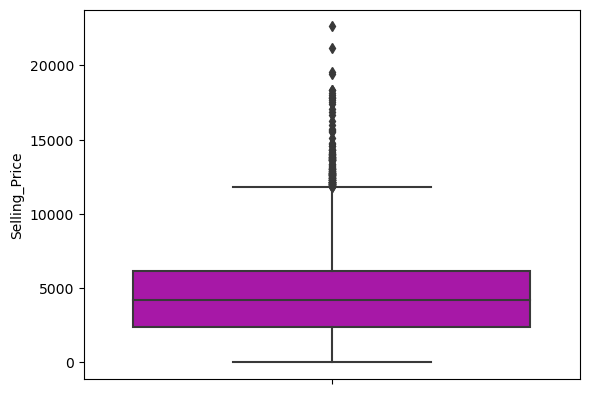

In [9]:
sns.boxplot( y="Selling_Price",color='m', data=train_data)

/var/folders/mk/psqrk12j3rjdspvkk75nx47m0000gn/T/ipykernel_5435/926681922.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data.charges_1,color='g')
/Users/Admin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


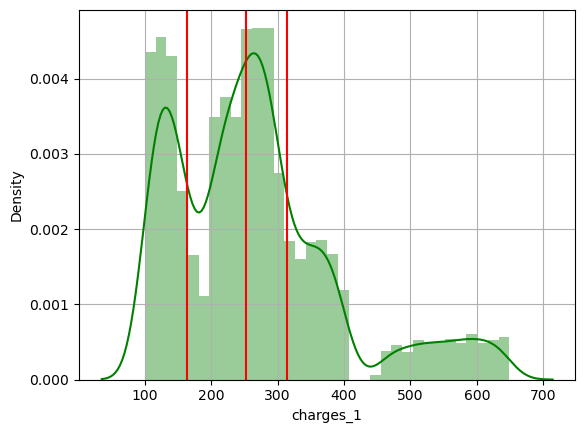

In [10]:
sns.distplot(train_data.charges_1,color='g')
plt.grid('True')
for x in [0.25,0.5,0.75]:
    plt.axvline(train_data.charges_1.quantile(x),c='r',lw=1.5)
plt.show()

/var/folders/mk/psqrk12j3rjdspvkk75nx47m0000gn/T/ipykernel_5435/2373671450.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['charges_2 (%)'],color='g')
/Users/Admin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


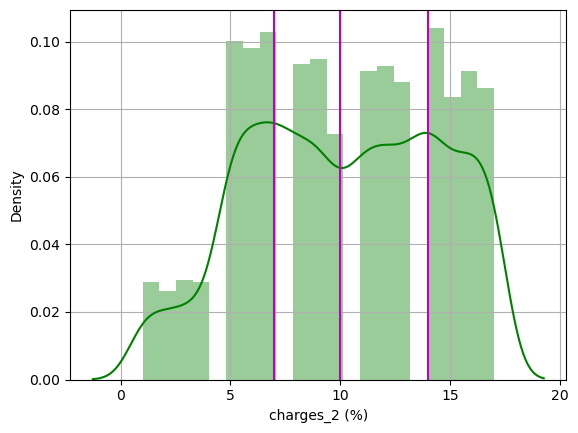

In [11]:
# Distplot of charges_2 (%)
sns.distplot(train_data['charges_2 (%)'],color='g')
plt.grid('True')
for x in [0.25,0.50,0.75]:
    plt.axvline(train_data['charges_2 (%)'].quantile(x),color='m',lw=1.5)
plt.show()

/var/folders/mk/psqrk12j3rjdspvkk75nx47m0000gn/T/ipykernel_5435/3549675430.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data.Minimum_price,color='r')
/Users/Admin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


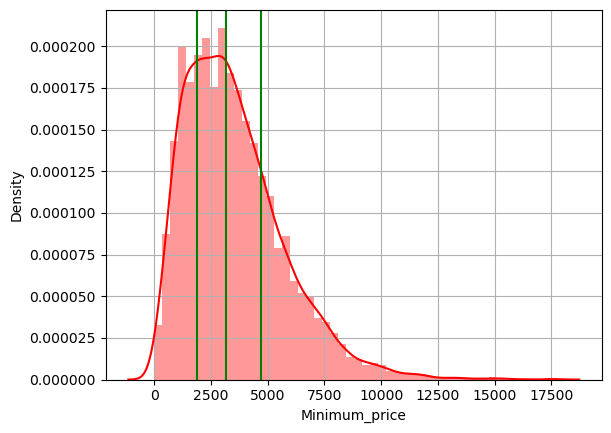

In [12]:
# Distplot of Minimum Price
sns.distplot(train_data.Minimum_price,color='r')
plt.grid('True')
for x in [0.25,0.50,0.75]:
    plt.axvline(train_data.Minimum_price.quantile(x),c='g',lw=1.5)
plt.show()

# Feature Engineering

In [13]:

def feature_engineering(data):
    
#     data = data.dropna().reset_index(drop=True)
    data["month"] = pd.to_datetime(data["instock_date"]).dt.month   
    data["day"] = pd.to_datetime(data["instock_date"]).dt.day   
    data["hour"] = pd.to_datetime(data["instock_date"]).dt.hour
    # Customer_Initial
    data["CI"] = data["Customer_name"].str[0]
    data = data.set_index("Product_id")
    columns = [
        "month", "day", "hour", "CI", "Stall_no", "Market_Category",
        "Loyalty_customer", "Product_Category", "Grade", "Demand", 
        "Discount_avail", "charges_1", "charges_2 (%)", "Minimum_price", 
        "Maximum_price"
    ]
    return data[columns]

X_train = feature_engineering(data=train_data.dropna(subset="Selling_Price"))
test_data = feature_engineering(data=test_data)

In [14]:
X_train.head(10)

,month,day,hour,CI,Stall_no,Market_Category,Loyalty_customer,Product_Category,Grade,Demand,Discount_avail,charges_1,charges_2 (%),Minimum_price,Maximum_price
Product_id,,,,,,,,,,,,,,,
BRAE2NF6JA5GUEXG,8,22,18,L,37.0,2,Yes,Fashion,1,68,0.0,376.0,11.0,2983.0,4713.0
TUNE8SFB6RJN2HSD,3,27,21,K,38.0,24,Yes,Fashion,0,51,0.0,397.0,12.0,7495.0,10352.0
BRAEAR7WZPQGPBZU,8,18,19,R,9.0,447,Yes,Child_care,0,10,0.0,250.0,9.0,5752.0,7309.0
WATDZ2ZQ8JPDHCTJ,3,28,21,A,50.0,23,Yes,Educational,2,48,0.0,144.0,13.0,5090.0,20814.0
JWSEBUKYQPMBZ3RK,3,29,22,D,7.0,63,Yes,Repair,1,35,1.0,211.0,4.0,2430.0,9261.0
SHIECAYW3VZWGZGX,9,25,16,B,23.0,162,No,Technology,1,49,0.0,633.0,6.0,3959.0,6104.0
SHOE4FZGGTE7HJXN,12,8,12,Z,33.0,462,No,Cosmetics,3,57,0.0,263.0,13.0,2006.0,5257.0
SHOE6QGAYFFMBWG6,9,22,14,K,4.0,23,Yes,Educational,1,67,0.0,104.0,15.0,3596.0,5921.0
KRTEBSMKCGFESHYX,3,28,21,T,26.0,156,Yes,Child_care,0,53,0.0,310.0,6.0,6965.0,10194.0


In [15]:
test_data.isnull().sum()

month                0
day                  0
hour                 0
CI                  53
Stall_no             1
Market_Category      0
Loyalty_customer     0
Product_Category     0
Grade                0
Demand               0
Discount_avail       0
charges_1           36
charges_2 (%)        5
Minimum_price       14
Maximum_price        0
dtype: int64

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

In [17]:
numerical_pipeline = Pipeline(
    steps=[
        ("impute", SimpleImputer()),
        ("standard_scaler", StandardScaler())
    ]
)
numerical_columns = ["month", "day", "hour", "Stall_no", "Grade", "Demand", "Market_Category",
        "Discount_avail", "charges_1", "charges_2 (%)", "Minimum_price", 
        "Maximum_price"]
pd.DataFrame(
    numerical_pipeline.fit_transform(X_train[numerical_columns]), 
    columns=numerical_pipeline.get_feature_names_out()
).head()

,month,day,hour,Stall_no,Grade,Demand,Market_Category,Discount_avail,charges_1,charges_2 (%),Minimum_price,Maximum_price
0,0.478121,0.509200,0.615459,0.816253,0.347618,0.587110,-1.159039,-0.405426,0.909921,0.200994,-0.250617,-0.475747
1,-1.025275,1.128984,1.050560,0.886074,-0.627981,0.002710,-1.029827,-0.405426,1.081318,0.436403,1.811541,1.084397
2,0.478121,0.013373,0.760493,-1.138751,-0.627981,-1.406727,1.454576,-0.405426,-0.118461,-0.269825,1.014923,0.242489
3,-1.025275,1.252940,1.050560,1.723933,1.323218,-0.100420,-1.035700,-0.405426,-0.983607,0.671813,0.712363,3.978922
4,-1.025275,1.376897,1.195593,-1.278394,0.347618,-0.547314,-0.800769,2.481351,-0.436769,-1.446873,-0.503359,0.782549


In [18]:
categorical_pipeline = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder())
    ]
)

categorical_columns = ["CI", "Loyalty_customer", "Product_Category"]

pd.DataFrame(
    categorical_pipeline.fit_transform(X_train[categorical_columns]), 
    columns=categorical_pipeline.get_feature_names_out()
).head()

,CI,Loyalty_customer,Product_Category
0,12.0,1.0,3.0
1,11.0,1.0,3.0
2,18.0,1.0,0.0
3,1.0,1.0,2.0
4,4.0,1.0,8.0


In [19]:
final_tranformer = ColumnTransformer(
    [
        ("num_pipeline", numerical_pipeline, numerical_columns),
        ("cat_pipeline", categorical_pipeline, categorical_columns)
    ],
    remainder="drop"
)
X_train = pd.DataFrame(
    final_tranformer.fit_transform(X=X_train),
    columns=final_tranformer.get_feature_names_out()
)
X_train.head()

,num_pipeline__month,num_pipeline__day,num_pipeline__hour,num_pipeline__Stall_no,num_pipeline__Grade,num_pipeline__Demand,num_pipeline__Market_Category,num_pipeline__Discount_avail,num_pipeline__charges_1,num_pipeline__charges_2 (%),num_pipeline__Minimum_price,num_pipeline__Maximum_price,cat_pipeline__CI,cat_pipeline__Loyalty_customer,cat_pipeline__Product_Category
0,0.478121,0.509200,0.615459,0.816253,0.347618,0.587110,-1.159039,-0.405426,0.909921,0.200994,-0.250617,-0.475747,12.0,1.0,3.0
1,-1.025275,1.128984,1.050560,0.886074,-0.627981,0.002710,-1.029827,-0.405426,1.081318,0.436403,1.811541,1.084397,11.0,1.0,3.0
2,0.478121,0.013373,0.760493,-1.138751,-0.627981,-1.406727,1.454576,-0.405426,-0.118461,-0.269825,1.014923,0.242489,18.0,1.0,0.0
3,-1.025275,1.252940,1.050560,1.723933,1.323218,-0.100420,-1.035700,-0.405426,-0.983607,0.671813,0.712363,3.978922,1.0,1.0,2.0
4,-1.025275,1.376897,1.195593,-1.278394,0.347618,-0.547314,-0.800769,2.481351,-0.436769,-1.446873,-0.503359,0.782549,4.0,1.0,8.0


In [20]:
X_test = pd.DataFrame(
    final_tranformer.transform(X=test_data),
    columns=final_tranformer.get_feature_names_out()
)
X_test.head()

,num_pipeline__month,num_pipeline__day,num_pipeline__hour,num_pipeline__Stall_no,num_pipeline__Grade,num_pipeline__Demand,num_pipeline__Market_Category,num_pipeline__Discount_avail,num_pipeline__charges_1,num_pipeline__charges_2 (%),num_pipeline__Minimum_price,num_pipeline__Maximum_price,cat_pipeline__CI,cat_pipeline__Loyalty_customer,cat_pipeline__Product_Category
0,-1.626633,-0.606411,-0.979911,0.955896,-0.627981,1.343394,0.033239,-0.405426,0.942568,1.378041,-0.436632,-0.855616,9.0,0.0,3.0
1,0.478121,0.633157,0.905526,1.654111,-0.627981,1.240264,-1.153166,-0.405426,1.048671,1.378041,-1.064603,-1.238804,9.0,1.0,3.0
2,1.380159,-0.482454,0.615459,-1.697323,1.323218,0.140216,-0.095973,-0.405426,1.864847,-0.269825,1.665289,2.568180,1.0,0.0,9.0
3,1.380159,0.385243,-1.415011,-1.208572,2.298817,1.205888,0.931853,-0.405426,0.314113,1.378041,0.855874,1.838600,18.0,1.0,0.0
4,-0.423916,-1.474108,0.180358,0.536966,-0.627981,-0.822326,-0.189946,-0.405426,2.468818,1.378041,0.245727,-0.052165,5.0,0.0,9.0


# Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, train_data["Selling_Price"], test_size=0.2, random_state=42) 

# Model Training

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, root_mean_squared_log_error

In [23]:
def model_training(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_test_pred=model.predict(X_val)
    y_train_pred=model.predict(X_train)
    
    print("Training Metrics : ")
    print("RMSE : ", root_mean_squared_error(y_true=y_train, y_pred=y_train_pred))  
    print("R2 Score : ", r2_score(y_true=y_train, y_pred=y_train_pred))
    
    print("Test Metrics : ")
    print("RMSE : ", root_mean_squared_error(y_true=y_val, y_pred=y_test_pred))  
    print("R2 Score : ", r2_score(y_true=y_val, y_pred=y_test_pred))
    
    return model
    

In [24]:
linear_model = LinearRegression()

model_training(
    model=linear_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

Training Metrics : 
RMSE :  1014.2781818937932
R2 Score :  0.88422748341555
Test Metrics : 
RMSE :  912.636826312963
R2 Score :  0.9033638087034446


LinearRegression()

In [25]:
rf_model = RandomForestRegressor()

model_training(
    model=rf_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

Training Metrics : 
RMSE :  226.15098292578506
R2 Score :  0.9942444309817535
Test Metrics : 
RMSE :  471.7276766009703
R2 Score :  0.9741817654989668


RandomForestRegressor()

In [26]:
final_model = model_training(
    model=rf_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

Training Metrics : 
RMSE :  229.98548083956234
R2 Score :  0.9940475994809215
Test Metrics : 
RMSE :  460.44199433437416
R2 Score :  0.9754023465237347


In [27]:
test_data["Selling_Price"] = final_model.predict(X_test)
test_data.head()

,month,day,hour,CI,Stall_no,Market_Category,Loyalty_customer,Product_Category,Grade,Demand,Discount_avail,charges_1,charges_2 (%),Minimum_price,Maximum_price,Selling_Price
Product_id,,,,,,,,,,,,,,,,
SCHE4YSTDVPVZVXW,1,13,7,I,39.0,205,No,Fashion,0,90,0,380.0,16.0,2576.0,3340,3276.089190
ACCEGCATKHNRXUHW,8,23,20,I,49.0,3,Yes,Fashion,0,87,0,393.0,16.0,1202.0,1955,1945.291621
NKCE6GJ5XVJDXNNZ,11,14,18,A,1.0,183,No,Technology,2,55,0,493.0,9.0,7175.0,15715,11473.444376
NKCEB8BK3ZXDHDHM,11,21,4,R,8.0,358,Yes,Child_care,3,86,0,303.0,16.0,5404.0,13078,9471.399782
TOPEFDXSAHRNPF94,5,6,15,E,33.0,167,No,Technology,0,27,0,567.0,16.0,4069.0,6244,5656.718008


In [28]:
final_submission = test_data[["Selling_Price"]].reset_index()
final_submission["Selling_Price"] = np.where(
    final_submission["Selling_Price"]<0, 0, final_submission["Selling_Price"]
)
final_submission["Selling_Price"]= final_submission["Selling_Price"].round(6)
final_submission.to_csv("final_submission.csv", index=False)